In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


file_path = 'D:\\DS Assignment\\Decision Tree\\Decision Tree\\heart_disease.xlsx'   # agar local pe hai toh path adjust karna
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
print("Sheets found:", sheet_names)

dfs = {name: xls.parse(name) for name in sheet_names}

df = dfs['Heart_disease'].copy()
df.head()


Sheets found: ['Description', 'Heart_disease']


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\n'num' value counts (original target):")
print(df['num'].value_counts())

print("\nNumeric description:")
print(df.describe())

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nObject columns:", cat_cols)



Shape: (908, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None

Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num         

In [ ]:
df['target'] = (df['num'] > 0).astype(int)
print("Binary target counts:\n", df['target'].value_counts())

for c in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in {c}:")
    print(df[c].unique())


Binary target counts:
 target
1    509
0    399
Name: count, dtype: int64

Unique values in sex:
['Male' 'Female']

Unique values in cp:
['typical angina' 'atypical angina' 'asymptomatic' 'non-anginal']

Unique values in restecg:
['lv hypertrophy' 'normal' 'st-t abnormality']

Unique values in exang:
[False True 'FALSE' 'TURE']

Unique values in slope:
['downsloping' 'flat' 'upsloping']

Unique values in thal:
['fixed defect' 'normal' 'reversable defect']


In [ ]:
def clean_exang(x):
    if isinstance(x, bool):
        return int(x)
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ['true', 'ture', '1', 'yes', 'y']:
        return 1
    if s in ['false', '0', 'no', 'n']:
        return 0
    return np.nan

df['exang_clean'] = df['exang'].apply(clean_exang).astype('float')

imp = SimpleImputer(strategy='median')
df['oldpeak_imputed'] = imp.fit_transform(df[['oldpeak']])

df['fbs_int'] = df['fbs'].astype(int)

df['sex_m'] = df['sex'].map({'Male':1, 'Female':0})

df_clean = df.drop(columns=['exang','fbs','sex','num'])

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

X = df_clean.drop(columns=['target'])
y = df_clean['target']

X = X.fillna(X.median(numeric_only=True)).fillna(0)


In [ ]:
numeric_cols = ['age','trestbps','chol','thalch','oldpeak_imputed']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6758241758241759
Precision: 0.7087378640776699
Recall: 0.7156862745098039
F1: 0.7121951219512195
ROC-AUC: 0.6703431372549019

Classification report:
               precision    recall  f1-score   support

           0       0.63      0.62      0.63        80
           1       0.71      0.72      0.71       102

    accuracy                           0.68       182
   macro avg       0.67      0.67      0.67       182
weighted avg       0.68      0.68      0.68       182

Confusion matrix:
 [[50 30]
 [29 73]]


Top features:
 exang_clean           0.207480
chol                  0.187453
thalch                0.118114
age                   0.106827
trestbps              0.089021
oldpeak_imputed       0.040700
cp_non-anginal        0.038590
cp_atypical angina    0.036201
sex_m                 0.028805
oldpeak               0.028733
dtype: float64


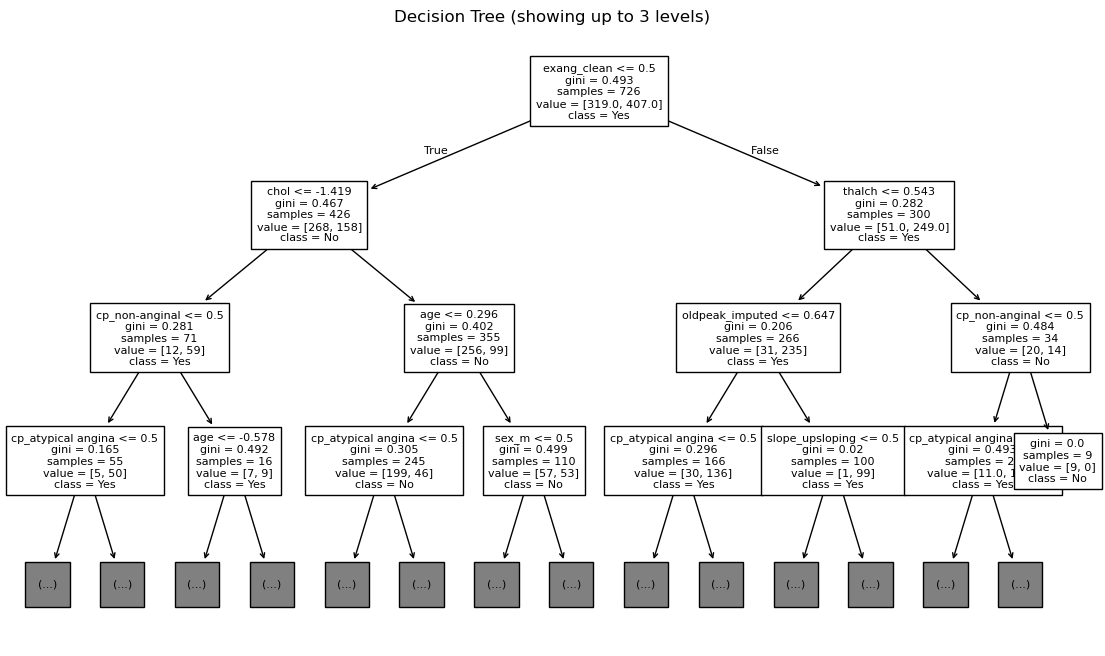

In [8]:
feat_imp = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top features:\n", feat_imp.head(10))


plt.figure(figsize=(14,8))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=False, max_depth=3, fontsize=8)
plt.title("Decision Tree (showing up to 3 levels)")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,9, None],
    'min_samples_split': [2,5,10],
    'criterion': ['gini','entropy']
}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV F1:", gs.best_score_)

best_dt = gs.best_estimator_
y_pred_best = best_dt.predict(X_test)
y_proba_best = best_dt.predict_proba(X_test)[:,1]
print("Test F1 of best:", f1_score(y_test, y_pred_best))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'criterion': 'gini', 'max_depth': 9, 'min_samples_split': 5}
Best CV F1: 0.7941293115486664
Test F1 of best: 0.7475728155339806
